# FIT5196 Assignment 2 - Task 2: Data Reshaping

**Group 024**  
**Dataset:** `suburb_info.xlsx`

This notebook prepares the suburb reference data for later linear modelling. The focus is not to build a final prediction model, but to profile the variables, compare scaling and transformation choices, and recommend a defensible reshaping strategy for the required features and target.

## Tutor Talking Points

When teaching this notebook, frame Task 2 as a Week 9 data-transformation exercise, not as a final modelling task. The key classroom questions are:

1. **Do the features live on comparable scales?** If not, scaling is needed before later modelling.
2. **Are the distributions skewed?** If yes, power/log transformations may make relationships easier for a linear model.
3. **Does transformation improve linear-model readiness?** Use skewness, correlation, scatterplots, and optional OLS diagnostics as evidence.
4. **Can we justify a final recommendation per variable?** The final table is the main teaching artifact.

Chinese teaching note: 这里重点不是“模型分数最高”, 而是让学生学会用证据判断是否需要 scaling / transformation.

## 1. Purpose and Workflow

This report follows the FIT5196 wrangling workflow: discovery, EDA/profile, transformation design, validation, and documentation. The analysis uses only `suburb_info.xlsx` and focuses on:

- converting percentage, currency, and comma-formatted fields into numeric columns;
- checking shape, columns, duplicates, and missingness;
- comparing feature scales, skewness, outliers, and relationships with `median_house_price`;
- evaluating Standard, Min-Max, and Robust scaling;
- evaluating log/log1p, square-root, Box-Cox, and Yeo-Johnson transformations;
- ending with one final recommendation per required variable.

In [1]:
# Imports and display setup
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')

DATA_PATH = Path('suburb_info.xlsx')
FEATURES = ['number_of_houses', 'number_of_units', 'population', 'aus_born_perc', 'median_income']
TARGET = 'median_house_price'
REQUIRED_COLUMNS = ['suburb', *FEATURES, TARGET]
print(f'Working directory: {Path.cwd()}')
print(f'Data file exists: {DATA_PATH.exists()}')

Working directory: /Users/songhaifan/Documents/GitHub/teaching-materials/courses/lincoin/materials/fit5196/ass2_2026
Data file exists: True


## 2. Discovery and Loading

The workbook contains suburb-level demographic and housing variables. Three fields arrive as formatted strings: `aus_born_perc`, `median_income`, and `median_house_price`. They are cleaned into numeric values before profiling.

In [2]:
raw = pd.read_excel(DATA_PATH)
print(f'Raw shape: {raw.shape}')
display(raw.head())
display(pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum()}))
print(f'Whole-row duplicate count: {raw.duplicated().sum()}')
print('Columns:', list(raw.columns))

Raw shape: (202, 8)


,suburb,number_of_houses,number_of_units,municipality,aus_born_perc,median_income,median_house_price,population
0,ABBOTSFORD,2304,4706,Yarra,68%,"$1,797","$1,299,400",4025
1,ABERFELDIE,1410,453,Moonee Valley,81%,"$1,571","$1,926,600",22442
2,ALBANVALE,1897,138,Brimbank,46%,$907,"$594,200",54005
3,ALBION,1389,1392,Brimbank,52%,$929,"$739,100",30677
4,ALPHINGTON,1729,1099,Darebin,73%,"$1,538","$1,729,600",9227


,dtype,missing
suburb,str,0
number_of_houses,int64,0
number_of_units,int64,0
municipality,str,0
aus_born_perc,str,0
median_income,str,0
median_house_price,str,0
population,int64,0


Whole-row duplicate count: 0
Columns: ['suburb', 'number_of_houses', 'number_of_units', 'municipality', 'aus_born_perc', 'median_income', 'median_house_price', 'population']


In [3]:
def clean_numeric(series: pd.Series) -> pd.Series:
    """Convert values such as '68%', '$1,797', and '$1,299,400' to numeric."""
    return pd.to_numeric(
        series.astype(str)
        .str.replace(r'[$,%]', '', regex=True)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace({'': np.nan, 'nan': np.nan, 'None': np.nan}),
        errors='coerce'
    )

suburb = raw.copy()
for col in ['aus_born_perc', 'median_income', 'median_house_price']:
    suburb[col] = clean_numeric(suburb[col])

# Ensure the remaining required modelling inputs are numeric as well.
for col in ['number_of_houses', 'number_of_units', 'population']:
    suburb[col] = pd.to_numeric(suburb[col], errors='coerce')

missing_required = [c for c in REQUIRED_COLUMNS if c not in suburb.columns]
if missing_required:
    raise ValueError(f'Missing required columns: {missing_required}')

profile = pd.DataFrame({
    'dtype_after_cleaning': suburb[REQUIRED_COLUMNS].dtypes.astype(str),
    'missing_after_cleaning': suburb[REQUIRED_COLUMNS].isna().sum(),
    'unique_values': suburb[REQUIRED_COLUMNS].nunique()
})
print(f'Cleaned shape: {suburb.shape}')
display(profile)
display(suburb[REQUIRED_COLUMNS].head())

Cleaned shape: (202, 8)


,dtype_after_cleaning,missing_after_cleaning,unique_values
suburb,str,0,202
number_of_houses,int64,0,198
number_of_units,int64,0,197
population,int64,0,135
aus_born_perc,int64,0,40
median_income,int64,0,129
median_house_price,int64,0,201


,suburb,number_of_houses,number_of_units,population,aus_born_perc,median_income,median_house_price
0,ABBOTSFORD,2304,4706,4025,68,1797,1299400
1,ABERFELDIE,1410,453,22442,81,1571,1926600
2,ALBANVALE,1897,138,54005,46,907,594200
3,ALBION,1389,1392,30677,52,929,739100
4,ALPHINGTON,1729,1099,9227,73,1538,1729600


## 3. Descriptive Statistics and Scale Comparison

The numeric features have very different units. Counts, percentages, weekly income, and prices should therefore be scaled before distance-based or regularised modelling. The table below provides the initial magnitude and spread evidence.

In [4]:
analysis_cols = FEATURES + [TARGET]
clean = suburb.dropna(subset=analysis_cols).copy()
print(f'Rows retained for numeric Task 2 analysis: {len(clean)} of {len(suburb)}')

desc = clean[analysis_cols].describe().T
desc['iqr'] = clean[analysis_cols].quantile(0.75) - clean[analysis_cols].quantile(0.25)
desc['range'] = desc['max'] - desc['min']
desc['skewness'] = clean[analysis_cols].skew()
desc['kurtosis'] = clean[analysis_cols].kurtosis()
display(desc)

Rows retained for numeric Task 2 analysis: 202 of 202


,count,mean,std,min,25%,50%,75%,max,iqr,range,skewness,kurtosis
number_of_houses,202.000,"4,155.767","3,400.865",283.000,"1,973.500","3,256.500","5,518.500","23,338.000","3,545.000","23,055.000",2.156,7.285
number_of_units,202.000,"2,480.411","3,132.685",60.000,620.500,"1,603.000","3,089.000","24,380.000","2,468.500","24,320.000",3.630,18.333
population,202.000,"18,659.312","9,604.187",170.000,"12,063.000","17,583.000","24,045.000","54,005.000","11,982.000","53,835.000",1.086,1.987
aus_born_perc,202.000,68.366,10.761,36.000,62.000,70.000,77.000,88.000,15.000,52.000,-0.568,-0.385
median_income,202.000,"1,387.936",317.841,633.000,"1,182.250","1,393.000","1,560.000","2,352.000",377.750,"1,719.000",0.173,0.050
median_house_price,202.000,"1,218,816.832","471,680.735","507,200.000","870,675.000","1,134,500.000","1,467,550.000","2,875,800.000","596,875.000","2,368,600.000",1.033,0.935


In [5]:
scale_summary = pd.DataFrame({
    'min': clean[FEATURES].min(),
    'max': clean[FEATURES].max(),
    'mean': clean[FEATURES].mean(),
    'std': clean[FEATURES].std(),
    'iqr': clean[FEATURES].quantile(0.75) - clean[FEATURES].quantile(0.25),
    'skewness': clean[FEATURES].skew(),
})
scale_summary['max_to_min_ratio'] = scale_summary['max'] / scale_summary['min'].replace(0, np.nan)
display(scale_summary.sort_values('std', ascending=False))

,min,max,mean,std,iqr,skewness,max_to_min_ratio
population,170,54005,"18,659.312","9,604.187","11,982.000",1.086,317.676
number_of_houses,283,23338,"4,155.767","3,400.865","3,545.000",2.156,82.466
number_of_units,60,24380,"2,480.411","3,132.685","2,468.500",3.630,406.333
median_income,633,2352,"1,387.936",317.841,377.750,0.173,3.716
aus_born_perc,36,88,68.366,10.761,15.000,-0.568,2.444


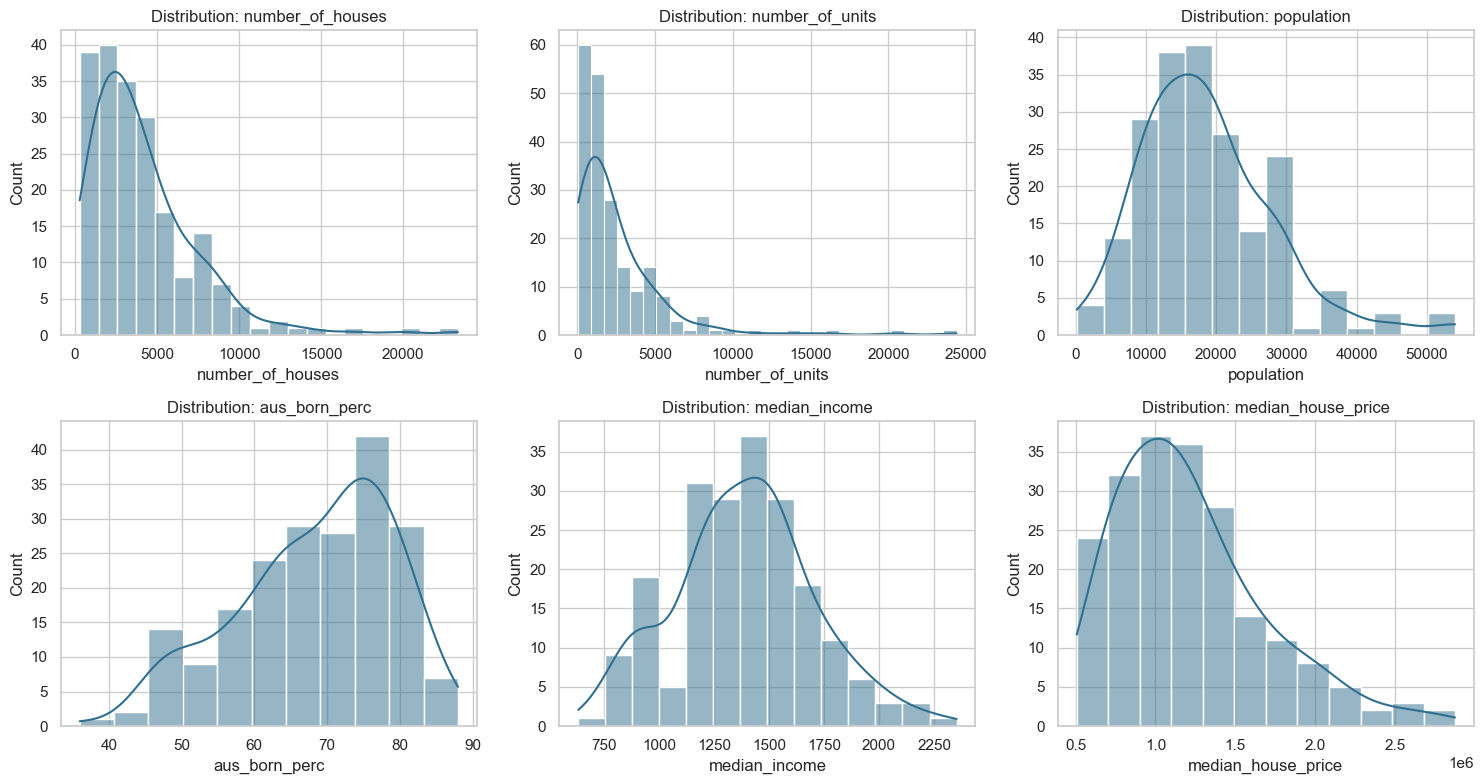

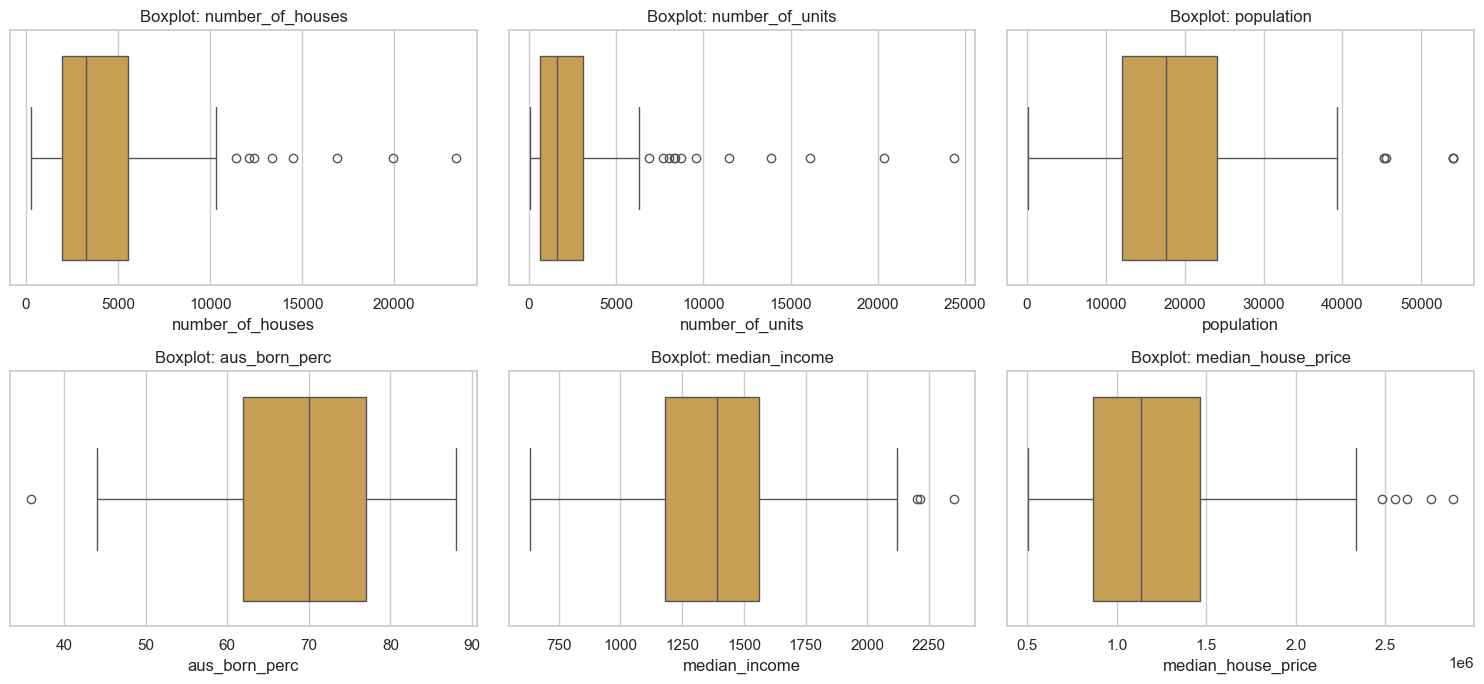

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, analysis_cols):
    sns.histplot(clean[col], kde=True, ax=ax, color='#2f6f8f')
    ax.set_title(f'Distribution: {col}')
    ax.set_xlabel(col)
for ax in axes.flat[len(analysis_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, analysis_cols):
    sns.boxplot(x=clean[col], ax=ax, color='#d9a441')
    ax.set_title(f'Boxplot: {col}')
for ax in axes.flat[len(analysis_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 4. Relationship With the Target

Both Pearson and Spearman correlations are useful here. Pearson measures linear association, while Spearman captures monotonic association that may still be non-linear before transformation.

,feature,pearson_r,pearson_p,spearman_r,spearman_p,abs_pearson_r,spearman_minus_pearson_abs
4,median_income,0.719,0.000,0.697,0.000,0.719,-0.022
1,number_of_units,0.344,0.000,0.309,0.000,0.344,-0.034
3,aus_born_perc,0.304,0.000,0.295,0.000,0.304,-0.009
2,population,-0.287,0.000,-0.243,0.000,0.287,-0.044
0,number_of_houses,-0.104,0.139,-0.058,0.416,0.104,-0.047


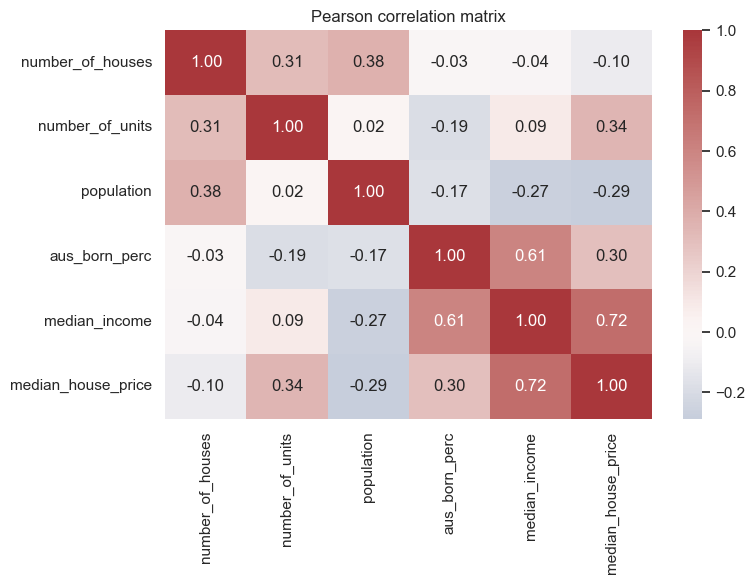

In [7]:
corr_rows = []
for col in FEATURES:
    pearson_r, pearson_p = stats.pearsonr(clean[col], clean[TARGET])
    spearman_r, spearman_p = stats.spearmanr(clean[col], clean[TARGET])
    corr_rows.append({
        'feature': col,
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_r': spearman_r,
        'spearman_p': spearman_p,
        'abs_pearson_r': abs(pearson_r),
        'spearman_minus_pearson_abs': abs(spearman_r) - abs(pearson_r),
    })
correlation_summary = pd.DataFrame(corr_rows).sort_values('abs_pearson_r', ascending=False)
display(correlation_summary)

plt.figure(figsize=(8, 6))
sns.heatmap(clean[analysis_cols].corr(method='pearson'), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Pearson correlation matrix')
plt.tight_layout()
plt.show()

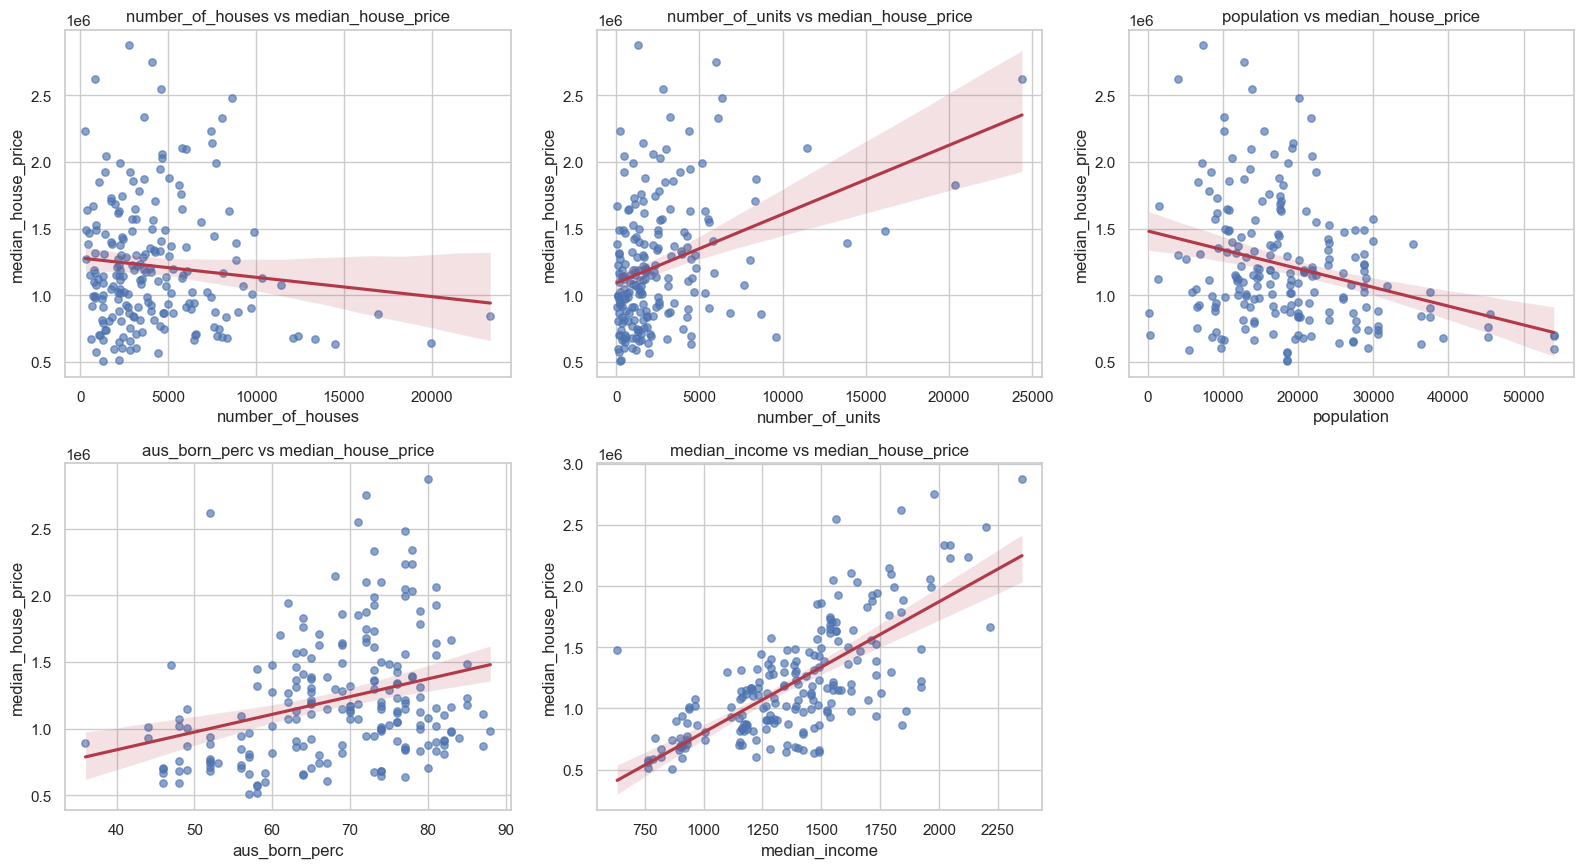

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, FEATURES):
    sns.regplot(data=clean, x=col, y=TARGET, ax=ax, scatter_kws={'alpha': 0.65, 's': 28}, line_kws={'color': '#b23a48'})
    ax.set_title(f'{col} vs {TARGET}')
for ax in axes.flat[len(FEATURES):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 5. Scaling Comparison

Scaling changes magnitude but not distribution shape. StandardScaler centres variables at mean 0 and standard deviation 1. MinMaxScaler maps values to 0-1 but is sensitive to extremes. RobustScaler centres by the median and scales by the IQR, which is useful where suburb counts have high leverage values.

In [9]:
scalers = {
    'standard': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler(),
}

scaled_summaries = []
for scaler_name, scaler in scalers.items():
    scaled = pd.DataFrame(scaler.fit_transform(clean[FEATURES]), columns=FEATURES, index=clean.index)
    for col in FEATURES:
        scaled_summaries.append({
            'scaler': scaler_name,
            'feature': col,
            'mean': scaled[col].mean(),
            'std': scaled[col].std(ddof=1),
            'min': scaled[col].min(),
            'median': scaled[col].median(),
            'max': scaled[col].max(),
            'iqr': scaled[col].quantile(0.75) - scaled[col].quantile(0.25),
            'skewness': scaled[col].skew(),
        })
scaling_comparison = pd.DataFrame(scaled_summaries)
display(scaling_comparison.pivot(index='feature', columns='scaler', values=['mean', 'std', 'min', 'max', 'iqr']))

mean                    std                    min         \
scaler           minmax robust standard minmax robust standard minmax robust   
feature                                                                        
aus_born_perc     0.622 -0.109    0.000  0.207  0.717    1.002  0.000 -2.267   
median_income     0.439 -0.013   -0.000  0.185  0.841    1.002  0.000 -2.012   
number_of_houses  0.168  0.254   -0.000  0.148  0.959    1.002  0.000 -0.839   
number_of_units   0.100  0.355   -0.000  0.129  1.269    1.002  0.000 -0.625   
population        0.343  0.090    0.000  0.178  0.802    1.002  0.000 -1.453   

                             max                    iqr                  
scaler           standard minmax robust standard minmax robust standard  
feature                                                                  
aus_born_perc      -3.015  1.000  1.200    1.829  0.288  1.000    1.397  
median_income      -2.381  1.000  2.539    3.041  0.220  1.000    1.191  
number_of_houses   -1.142  1.000  5.665    5.654  0.154  1.000    1.045  
number_of_units    -0.775  1.000  9.227    7.008  0.102  1.000    0.790  
population         -1.930  1.000  3.040    3.689  0.223  1.000    1.251

## 6. Transformation Comparison

The candidate transformations are evaluated by:

- reducing absolute skewness;
- preserving or improving linear association with `median_house_price`;
- avoiding transformations that are unsuitable for the data range;
- using simple OLS diagnostics only as supporting evidence, not as the final assignment deliverable.

In [10]:
def transformed_versions(series: pd.Series) -> dict:
    s = series.astype(float)
    versions = {'identity': s}
    if (s >= 0).all():
        versions['log1p'] = np.log1p(s)
        versions['sqrt'] = np.sqrt(s)
    if (s > 0).all():
        bc_values, bc_lambda = boxcox(s)
        versions[f'boxcox(lambda={bc_lambda:.3f})'] = pd.Series(bc_values, index=s.index)
    yj = PowerTransformer(method='yeo-johnson', standardize=False)
    yj_values = yj.fit_transform(s.to_frame()).ravel()
    versions[f'yeojohnson(lambda={yj.lambdas_[0]:.3f})'] = pd.Series(yj_values, index=s.index)
    return versions

transform_rows = []
transformed_store = {}
for col in analysis_cols:
    transformed_store[col] = transformed_versions(clean[col])
    for method, values in transformed_store[col].items():
        valid = pd.concat([values.rename('x'), clean[TARGET]], axis=1).dropna()
        pearson_r = np.nan
        spearman_r = np.nan
        if col != TARGET and valid['x'].nunique() > 1:
            pearson_r = stats.pearsonr(valid['x'], valid[TARGET])[0]
            spearman_r = stats.spearmanr(valid['x'], valid[TARGET])[0]
        transform_rows.append({
            'variable': col,
            'method': method,
            'skewness': values.skew(),
            'abs_skewness': abs(values.skew()),
            'pearson_r_with_target': pearson_r,
            'spearman_r_with_target': spearman_r,
            'abs_pearson_r_with_target': abs(pearson_r) if pd.notna(pearson_r) else np.nan,
        })

transform_comparison = pd.DataFrame(transform_rows)
display(transform_comparison.sort_values(['variable', 'abs_skewness']))

,variable,method,skewness,abs_skewness,pearson_r_with_target,spearman_r_with_target,abs_pearson_r_with_target
19,aus_born_perc,yeojohnson(lambda=2.486),-0.128,0.128,0.279,0.295,0.279
18,aus_born_perc,boxcox(lambda=2.461),-0.129,0.129,0.279,0.295,0.279
15,aus_born_perc,identity,-0.568,0.568,0.304,0.295,0.304
17,aus_born_perc,sqrt,-0.738,0.738,0.310,0.295,0.310
16,aus_born_perc,log1p,-0.917,0.917,0.315,0.295,0.315
28,median_house_price,boxcox(lambda=-0.196),0.014,0.014,NaN,NaN,NaN
29,median_house_price,yeojohnson(lambda=-0.196),0.014,0.014,NaN,NaN,NaN
26,median_house_price,log1p,0.173,0.173,NaN,NaN,NaN
27,median_house_price,sqrt,0.593,0.593,NaN,NaN,NaN
25,median_house_price,identity,1.033,1.033,NaN,NaN,NaN


In [11]:
best_by_skew = (transform_comparison
    .sort_values(['variable', 'abs_skewness'])
    .groupby('variable', as_index=False)
    .first()[['variable', 'method', 'skewness', 'abs_skewness']])

best_by_corr = (transform_comparison[transform_comparison['variable'].isin(FEATURES)]
    .sort_values(['variable', 'abs_pearson_r_with_target'], ascending=[True, False])
    .groupby('variable', as_index=False)
    .first()[['variable', 'method', 'pearson_r_with_target', 'abs_pearson_r_with_target']])

print('Best transformation by skewness:')
display(best_by_skew)
print('Best feature transformation by absolute Pearson correlation with target:')
display(best_by_corr)

Best transformation by skewness:


,variable,method,skewness,abs_skewness
0,aus_born_perc,yeojohnson(lambda=2.486),-0.128,0.128
1,median_house_price,boxcox(lambda=-0.196),0.014,0.014
2,median_income,yeojohnson(lambda=0.733),-0.008,0.008
3,number_of_houses,boxcox(lambda=0.183),-0.006,0.006
4,number_of_units,yeojohnson(lambda=0.126),-0.014,0.014
5,population,sqrt,-0.029,0.029


Best feature transformation by absolute Pearson correlation with target:


,variable,method,pearson_r_with_target,abs_pearson_r_with_target
0,aus_born_perc,log1p,0.315,0.315
1,median_income,identity,0.719,0.719
2,number_of_houses,identity,-0.104,0.104
3,number_of_units,sqrt,0.355,0.355
4,population,identity,-0.287,0.287


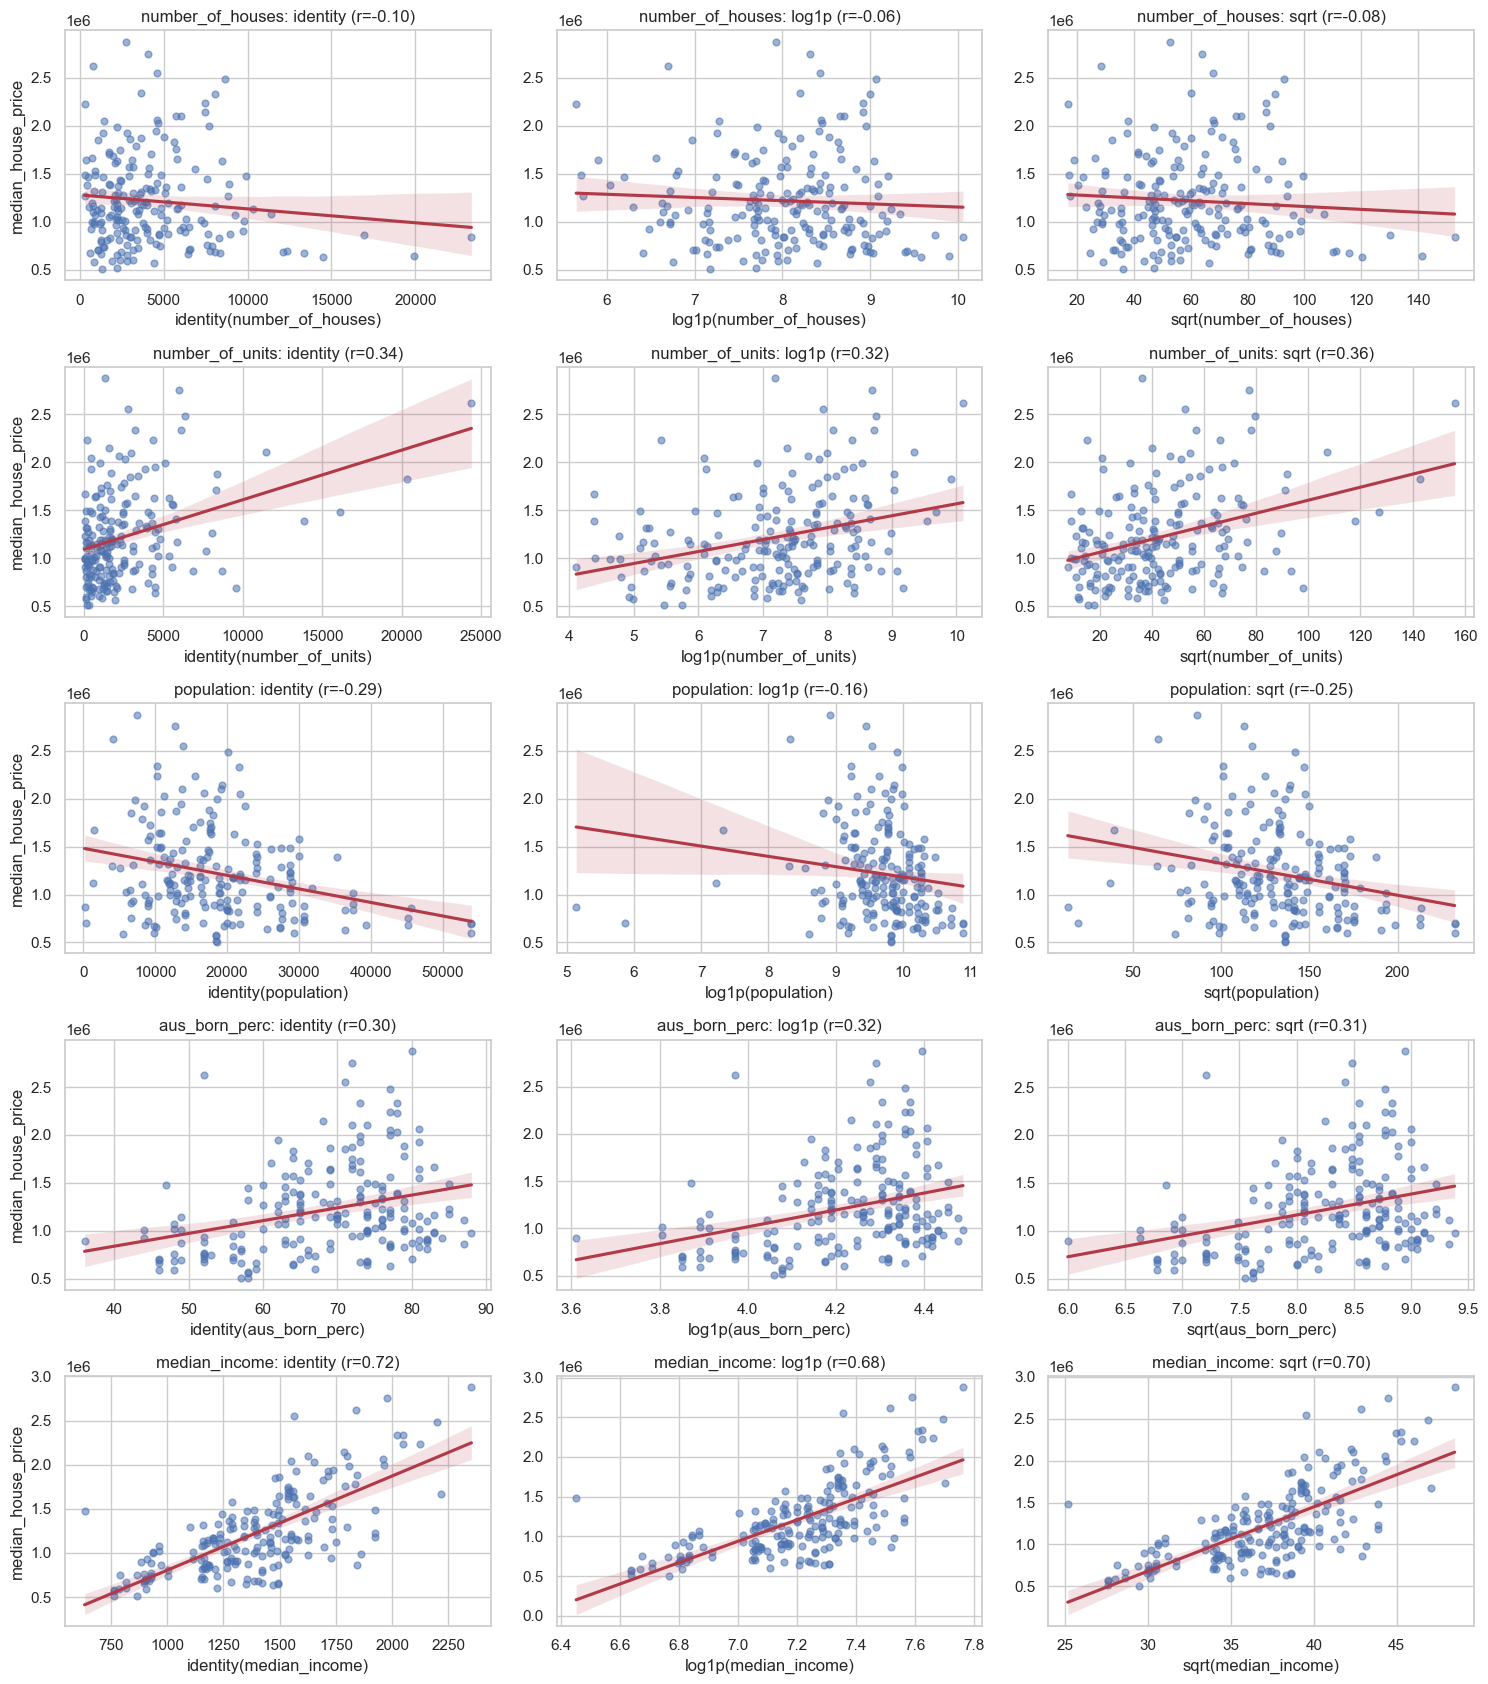

In [12]:
plot_methods = ['identity', 'log1p', 'sqrt']
fig, axes = plt.subplots(len(FEATURES), len(plot_methods), figsize=(15, 17))
for row, col in enumerate(FEATURES):
    versions = transformed_store[col]
    for j, method in enumerate(plot_methods):
        ax = axes[row, j]
        if method in versions:
            x = versions[method]
            sns.regplot(x=x, y=clean[TARGET], ax=ax, scatter_kws={'alpha': 0.55, 's': 24}, line_kws={'color': '#b23a48'})
            r = stats.pearsonr(x, clean[TARGET])[0]
            ax.set_title(f'{col}: {method} (r={r:.2f})')
            ax.set_xlabel(f'{method}({col})')
            ax.set_ylabel(TARGET if j == 0 else '')
        else:
            ax.set_visible(False)
plt.tight_layout()
plt.show()

## 7. Optional Linear Diagnostics

The task does not require a predictive model. The following simple OLS comparisons are used only to test whether recommended reshaping improves linear-model readiness. The comparison looks at adjusted R-squared, residual skewness, and residual spread.

In [13]:
import statsmodels.api as sm

manual_transform_plan = {
    'number_of_houses': 'yeojohnson',
    'number_of_units': 'yeojohnson',
    'population': 'yeojohnson',
    'aus_born_perc': 'identity',
    'median_income': 'identity',
}

def apply_named_transform(series: pd.Series, method_key: str) -> pd.Series:
    versions = transformed_store[series.name]
    if method_key == 'identity':
        return versions['identity']
    for name, values in versions.items():
        if name.startswith(method_key):
            return values
    raise KeyError(f'No transform starting with {method_key!r} for {series.name}')

X_raw = sm.add_constant(clean[FEATURES])
y_raw = clean[TARGET]
raw_model = sm.OLS(y_raw, X_raw).fit()

reshaped_features = pd.DataFrame(index=clean.index)
for col, method in manual_transform_plan.items():
    reshaped_features[col] = apply_named_transform(clean[col].rename(col), method)
reshaped_features = pd.DataFrame(StandardScaler().fit_transform(reshaped_features), columns=FEATURES, index=clean.index)
X_reshaped = sm.add_constant(reshaped_features)
reshaped_model = sm.OLS(y_raw, X_reshaped).fit()

diagnostics = pd.DataFrame([
    {
        'design': 'raw_features',
        'adj_r_squared': raw_model.rsquared_adj,
        'aic': raw_model.aic,
        'residual_skewness': pd.Series(raw_model.resid).skew(),
        'residual_std': pd.Series(raw_model.resid).std(),
    },
    {
        'design': 'recommended_transforms_plus_standard_scaling',
        'adj_r_squared': reshaped_model.rsquared_adj,
        'aic': reshaped_model.aic,
        'residual_skewness': pd.Series(reshaped_model.resid).skew(),
        'residual_std': pd.Series(reshaped_model.resid).std(),
    },
])
display(diagnostics)

,design,adj_r_squared,aic,residual_skewness,residual_std
0,raw_features,0.627,"5,657.780",0.195,"284,430.877"
1,recommended_transforms_plus_standard_scaling,0.671,"5,632.782",0.393,"267,364.591"


## 8. Final Recommendation

The final strategy balances statistical evidence and interpretability. Highly skewed count variables should be power-transformed before scaling. Bounded percentage and income fields are already comparatively well behaved, so they can remain in original shape and be scaled only when required by the later modelling algorithm.

In [14]:
recommendation_table = pd.DataFrame([
    {
        'variable': 'number_of_houses',
        'role': 'feature',
        'recommended_transformation': 'Yeo-Johnson power transform',
        'recommended_scaling': 'StandardScaler after transformation',
        'reason': 'House counts are on a large scale and moderately right-skewed; a power transform reduces skew while preserving all positive values.'
    },
    {
        'variable': 'number_of_units',
        'role': 'feature',
        'recommended_transformation': 'Yeo-Johnson power transform',
        'recommended_scaling': 'RobustScaler or StandardScaler after transformation',
        'reason': 'Unit counts have the strongest long-tail behaviour and visible high-leverage suburbs; Yeo-Johnson reduces skew and RobustScaler is useful if extremes remain influential.'
    },
    {
        'variable': 'population',
        'role': 'feature',
        'recommended_transformation': 'Yeo-Johnson power transform',
        'recommended_scaling': 'StandardScaler after transformation',
        'reason': 'Population is count-based and much larger in magnitude than other variables; transformation and scaling make it more comparable for linear modelling.'
    },
    {
        'variable': 'aus_born_perc',
        'role': 'feature',
        'recommended_transformation': 'Keep original numeric percentage',
        'recommended_scaling': 'StandardScaler if modelling uses scaled inputs',
        'reason': 'This bounded percentage has a clearer interpretation in its original form and does not need an aggressive distributional transform.'
    },
    {
        'variable': 'median_income',
        'role': 'feature',
        'recommended_transformation': 'Keep original numeric income, or use light Yeo-Johnson only if diagnostics require it',
        'recommended_scaling': 'StandardScaler if modelling uses scaled inputs',
        'reason': 'Income is less skewed than the count variables and has direct interpretability; scaling addresses its larger dollar magnitude.'
    },
    {
        'variable': 'median_house_price',
        'role': 'target',
        'recommended_transformation': 'Consider log1p or Yeo-Johnson for later modelling diagnostics',
        'recommended_scaling': 'Do not scale unless required by a specific modelling workflow',
        'reason': 'The target is right-skewed; a log-style transform can stabilise variance, but the final decision should depend on residual diagnostics and interpretability requirements.'
    },
])
display(recommendation_table)

,variable,role,recommended_transformation,recommended_scaling,reason
0,number_of_houses,feature,Yeo-Johnson power transform,StandardScaler after transformation,House counts are on a large scale and moderate...
1,number_of_units,feature,Yeo-Johnson power transform,RobustScaler or StandardScaler after transform...,Unit counts have the strongest long-tail behav...
2,population,feature,Yeo-Johnson power transform,StandardScaler after transformation,Population is count-based and much larger in m...
3,aus_born_perc,feature,Keep original numeric percentage,StandardScaler if modelling uses scaled inputs,This bounded percentage has a clearer interpre...
4,median_income,feature,"Keep original numeric income, or use light Yeo...",StandardScaler if modelling uses scaled inputs,Income is less skewed than the count variables...
5,median_house_price,target,Consider log1p or Yeo-Johnson for later modell...,Do not scale unless required by a specific mod...,The target is right-skewed; a log-style transf...


## 9. Conclusion

The recommended Task 2 preparation is to clean all required variables into numeric form, retain complete suburb rows, apply power transformations to the count-based features (`number_of_houses`, `number_of_units`, and `population`), keep `aus_born_perc` and `median_income` in interpretable numeric form unless later diagnostics require otherwise, and scale the final feature matrix for modelling.

This step follows the FIT5196 cleansing workflow: audit the issue, choose a rule-based or model-based fix, then verify that no new inconsistency is introduced.